<a href="https://colab.research.google.com/github/Kitossan22/HDAC11-SAR-Analysis/blob/main/HDAC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# HDAC11 Inhibitor SAR Analysis
## Bis-aryl sulfate (Series D) vs Sulfamate (EVB) series

# This notebook presents a structure-activity relationship (SAR) analysis of two
# HDAC11 inhibitor series using RDKit and pandas:

# - **Series D**: Bis-aryl sulfate scaffold (12 compounds) — from Christian A. Olsen, *JACS Au* 2024
# - **EVB series**: Sulfamate scaffold (5 tested compounds) — from Balatsos, MSc Thesis, KU 2025

# **Key question:** Do the same physicochemical trends drive potency across both scaffolds?

# Author: Marcos San Segundo Eizaguirre | Postdoctoral Researcher, University of Copenhagen

In [ ]:
!pip install rdkit seaborn -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
from rdkit.Chem.Draw import MolsToGridImage
from IPython.display import display
import seaborn as sns

In [ ]:
## 1. Series D — Bis-aryl Sulfate Scaffold
# Source: Christian A. Olsen, *JACS Au* 2024, DOI: 10.1021/jacsau.4c00042

# 12 compounds with HDAC11 Ki values (nM). Scaffold: aryl sulfate ZBG with hydroxamate cap.

In [ ]:
smiles_D = [
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2ccccc2)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2ccc(Br)cc2)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2ccc(C(F)(F)F)cc2)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2cccc(-c3ccccc3)c2)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2cccc(C(C)C)c2)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2ccc(C(C)C)cc2)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2cccc(C(C)(C)C)c2)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2ccc(C(C)(C)C)cc2)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2ccc(C(C)(C)C)cc2C)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2ccc(Oc3ccccc3)cc2)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2ccc(-n3ccnc3)cc2)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2ccc3ccccc3c2)c1C",
]
ids_D = ["D1","D2","D3","D4","D8","D9","D11","D12","D19","D21","D23","D24"]
hdac11_ki_D = {
    "D1":  2495, "D2":  457, "D3":  187, "D4":  272,
    "D8":   714, "D9":  178, "D11": 646, "D12": 581,
    "D19":  542, "D21": 149, "D23":1032, "D24": 458,
}

df_D = pd.DataFrame({"ID": ids_D, "SMILES": smiles_D})
df_D["Mol"]      = df_D["SMILES"].apply(Chem.MolFromSmiles)
df_D             = df_D[df_D["Mol"].notna()].copy()
df_D["MW"]       = df_D["Mol"].apply(Descriptors.MolWt)
df_D["LogP"]     = df_D["Mol"].apply(Descriptors.MolLogP)
df_D["HBD"]      = df_D["Mol"].apply(Descriptors.NumHDonors)
df_D["HBA"]      = df_D["Mol"].apply(Descriptors.NumHAcceptors)
df_D["TPSA"]     = df_D["Mol"].apply(Descriptors.TPSA)
df_D["RotBonds"] = df_D["Mol"].apply(Descriptors.NumRotatableBonds)
df_D["Ki_nM"]    = df_D["ID"].map(hdac11_ki_D)

def tier_D(ki):
    if ki < 200:   return "Potent"
    elif ki < 500: return "Moderate"
    elif ki < 800: return "Weak"
    else:          return "Inactive"

color_map = {"Potent": "tomato", "Moderate": "darkorange", "Weak": "gold", "Inactive": "steelblue"}
df_D["Tier"]  = df_D["Ki_nM"].apply(tier_D)
df_D["Color"] = df_D["Tier"].map(color_map)

print(df_D[["ID","Ki_nM","Tier","MW","LogP","TPSA","RotBonds"]].to_string(index=False))

 ID  Ki_nM     Tier      MW    LogP   TPSA  RotBonds
 D1   2495 Inactive 323.326 1.81662 101.93         5
 D2    457 Moderate 402.222 2.57912 101.93         5
 D3    187   Potent 391.323 2.83542 101.93         5
 D4    272 Moderate 399.424 3.48362 101.93         6
 D8    714     Weak 365.407 2.94002 101.93         6
 D9    178   Potent 365.407 2.94002 101.93         6
D11    646     Weak 379.434 3.11412 101.93         5
D12    581     Weak 379.434 3.11412 101.93         5
D19    542     Weak 393.461 3.42254 101.93         5
D21    149   Potent 415.423 3.60892 111.16         7
D23   1032 Inactive 389.389 2.00232 119.75         6
D24    458 Moderate 373.386 2.96982 101.93         5


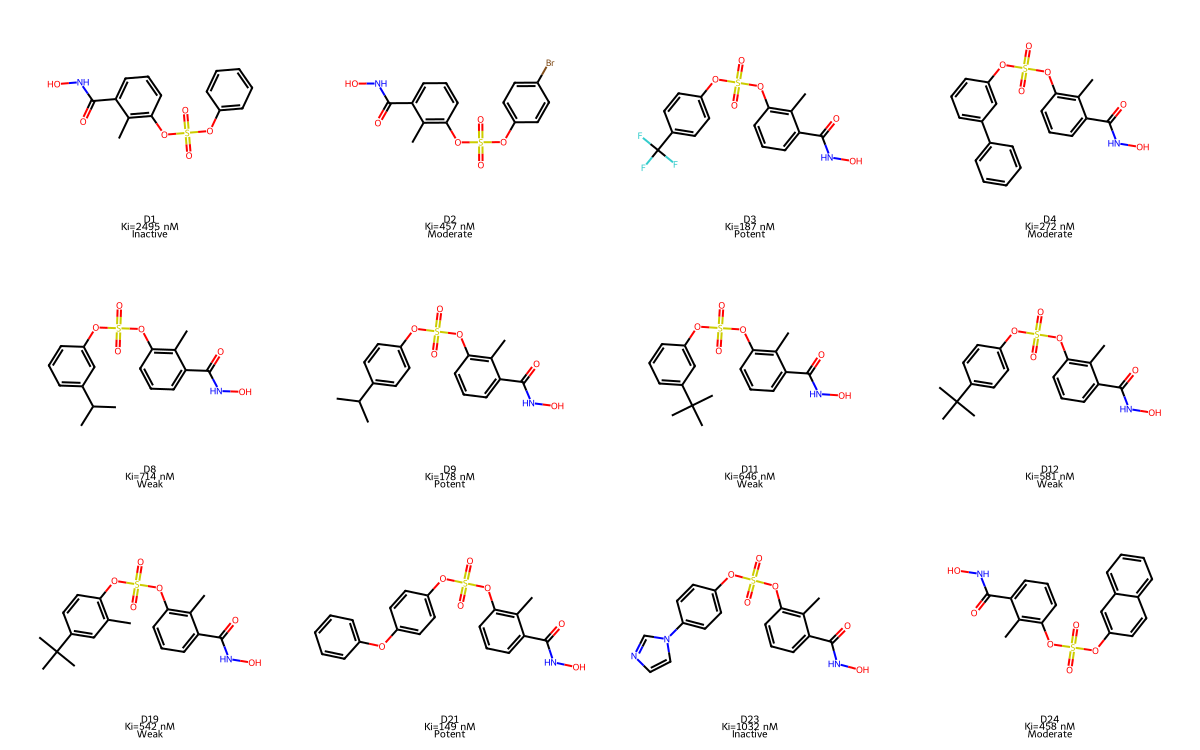

In [ ]:
mols_D    = list(df_D["Mol"])
labels_D  = [f"{row['ID']}\nKi={row['Ki_nM']} nM\n{row['Tier']}"
             for _, row in df_D.iterrows()]

img = MolsToGridImage(
    mols_D,
    molsPerRow=4,
    subImgSize=(300, 250),
    legends=labels_D
)
display(img)

In [ ]:
## 2. EVB Sulfamate Series
# Source: Balatsos, E. MSc Thesis, University of Copenhagen, 2025 (co-supervised with C. Olsen)

# Sulfamate ZBG with benzylamine cap group variations. 5 compounds with HDAC11 Ki values.

In [ ]:
evb_data = [
    ("19", "4-CF3",        "CC3=C(C(NO)=O)C=CC=C3OS(NCC4=CC=C(C(F)(F)F)C=C4)(=O)=O",   79),
    ("20", "3-CF3",        "CC7=C(C(NO)=O)C=CC=C7OS(NCC8=CC(C(F)(F)F)=CC=C8)(=O)=O",   82),
    ("11", "2-Br",         "CC%21=C(C(NO)=O)C=CC=C%21OS(NCC%22=CC=CC=C%22Br)(=O)=O",   92),
    ("30", "N-Me (lead)",  "CC%23=C(C(NO)=O)C=CC=C%23OS(N(C)CC%24=CC=CC=C%24)(=O)=O",  68),
    ("34", "3,5-bis-CF3",  "CC%34=C(C(NO)=O)C=CC=C%34OS(NCC%35=CC(C(F)(F)F)=CC(C(F)(F)F)=C%35)(=O)=O", 93),
]

df_evb = pd.DataFrame(evb_data, columns=["ID","Cap_Group","SMILES","Ki_nM"])
df_evb["Mol"]      = df_evb["SMILES"].apply(Chem.MolFromSmiles)
df_evb             = df_evb[df_evb["Mol"].notna()].copy()
df_evb["MW"]       = df_evb["Mol"].apply(Descriptors.MolWt)
df_evb["LogP"]     = df_evb["Mol"].apply(Descriptors.MolLogP)
df_evb["HBD"]      = df_evb["Mol"].apply(Descriptors.NumHDonors)
df_evb["HBA"]      = df_evb["Mol"].apply(Descriptors.NumHAcceptors)
df_evb["TPSA"]     = df_evb["Mol"].apply(Descriptors.TPSA)
df_evb["RotBonds"] = df_evb["Mol"].apply(Descriptors.NumRotatableBonds)

def tier_evb(ki):
    if ki < 75:   return "Potent"
    elif ki < 90: return "Moderate"
    else:         return "Weak"

df_evb["Tier"]  = df_evb["Ki_nM"].apply(tier_evb)
df_evb["Color"] = df_evb["Tier"].map(color_map)

print(df_evb[["ID","Cap_Group","Ki_nM","Tier","MW","LogP","TPSA","RotBonds"]].to_string(index=False))

ID   Cap_Group  Ki_nM     Tier      MW    LogP   TPSA  RotBonds
19       4-CF3     79 Moderate 404.366 2.54622 104.73         6
20       3-CF3     82 Moderate 404.366 2.54622 104.73         6
11        2-Br     92     Weak 415.265 2.28992 104.73         6
30 N-Me (lead)     68   Potent 350.396 1.86962  95.94         6
34 3,5-bis-CF3     93     Weak 472.363 3.56502 104.73         6


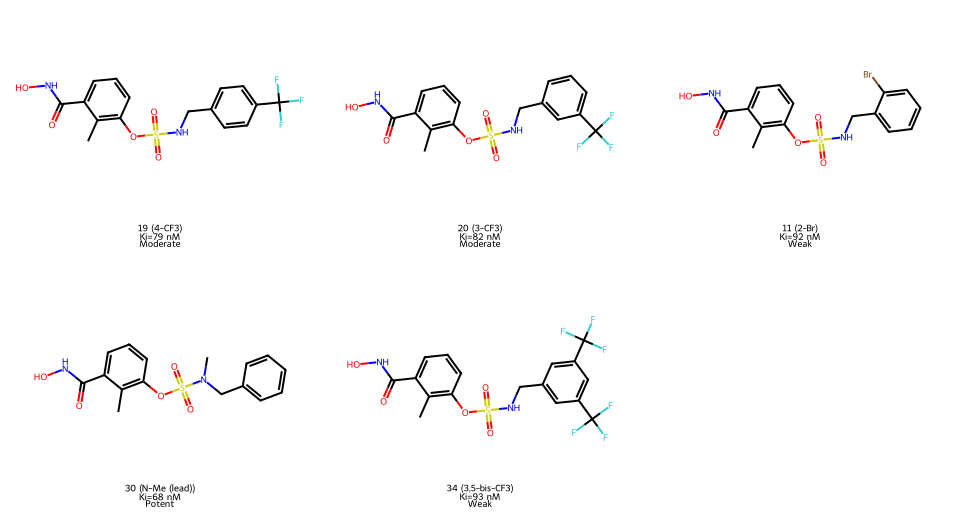

In [ ]:
mols_evb   = list(df_evb["Mol"])
labels_evb = [f"{row['ID']} ({row['Cap_Group']})\nKi={row['Ki_nM']} nM\n{row['Tier']}"
              for _, row in df_evb.iterrows()]

img_evb = MolsToGridImage(
    mols_evb,
    molsPerRow=3,
    subImgSize=(320, 260),
    legends=labels_evb
)
display(img_evb)

In [ ]:
## 3. SAR Analysis — Descriptor vs Activity Plots

# Comparing physicochemical descriptors (MW, LogP, TPSA, RotBonds) against HDAC11 Ki
# across both series. Circles = Series D (sulfate), Triangles = EVB (sulfamate).
# Activity thresholds shown as dashed lines.

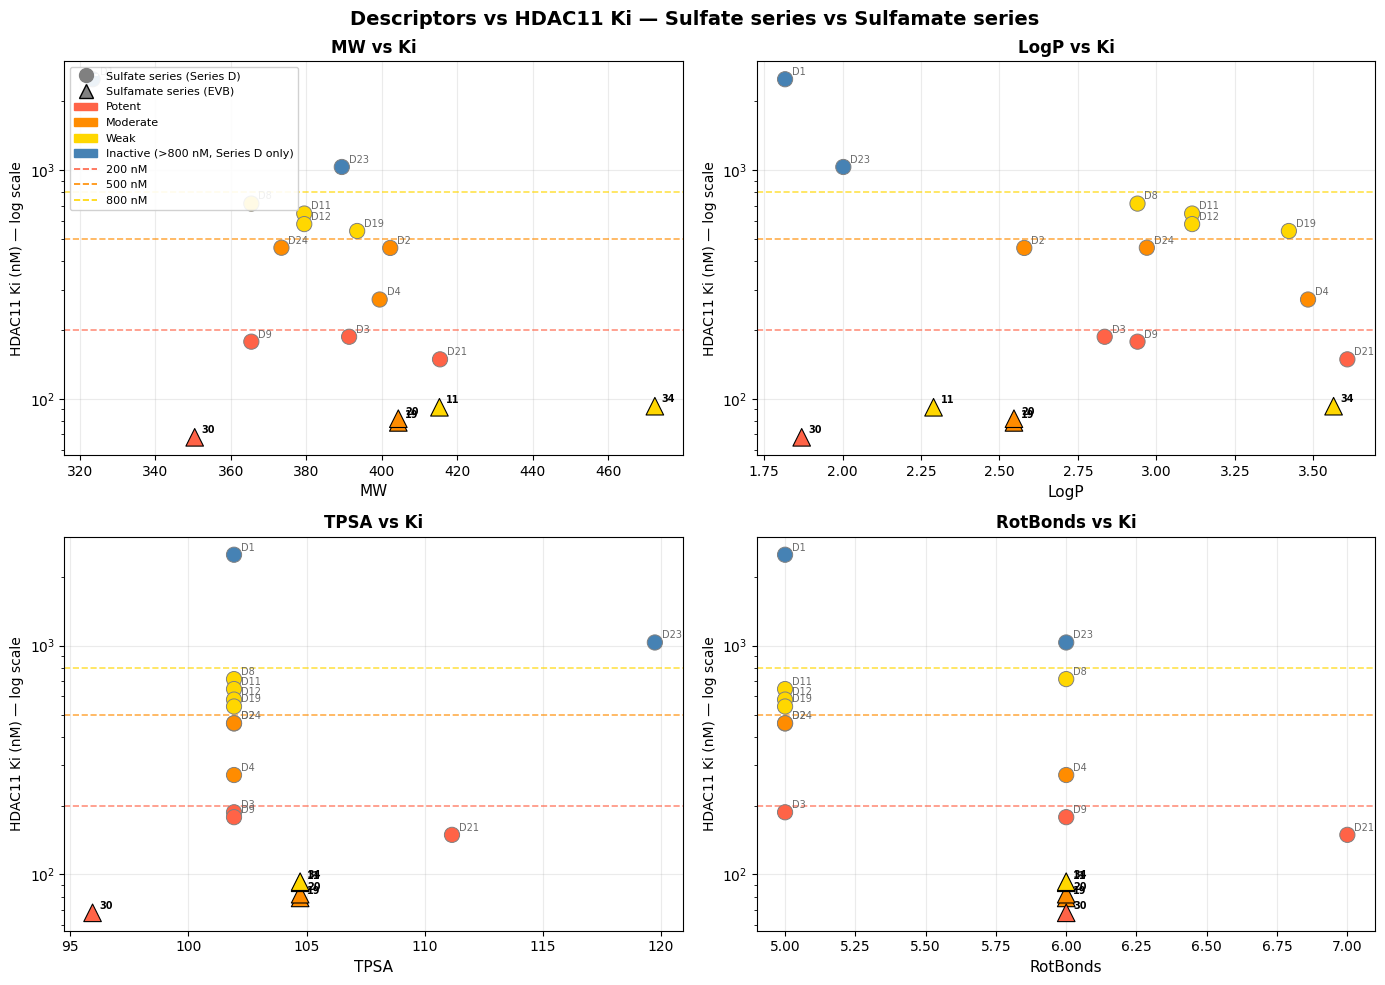

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Descriptors vs HDAC11 Ki — Sulfate series vs Sulfamate series",
             fontsize=14, fontweight="bold")

axes  = axes.flatten()
descs = ["MW", "LogP", "TPSA", "RotBonds"]

for ax, desc in zip(axes, descs):

    # Series D — circles
    ax.scatter(df_D[desc], df_D["Ki_nM"],
               c=df_D["Color"], s=120, marker="o",
               edgecolors="gray", linewidths=0.7, zorder=3)
    for _, row in df_D.iterrows():
        ax.annotate(row["ID"], (row[desc], row["Ki_nM"]),
                    fontsize=7, color="dimgray",
                    textcoords="offset points", xytext=(5, 3))

    # EVB — triangles
    ax.scatter(df_evb[desc], df_evb["Ki_nM"],
               c=df_evb["Color"], s=160, marker="^",
               edgecolors="black", linewidths=0.8, zorder=5)
    for _, row in df_evb.iterrows():
        ax.annotate(row["ID"], (row[desc], row["Ki_nM"]),
                    fontsize=7, color="black", fontweight="bold",
                    textcoords="offset points", xytext=(5, 3))

    ax.set_yscale("log")
    ax.set_xlabel(desc, fontsize=11)
    ax.set_ylabel("HDAC11 Ki (nM) — log scale", fontsize=10)
    ax.set_title(f"{desc} vs Ki", fontsize=12, fontweight="bold")
    ax.axhline(200, color="tomato",     linestyle="--", linewidth=1.2, alpha=0.7)
    ax.axhline(500, color="darkorange", linestyle="--", linewidth=1.2, alpha=0.7)
    ax.axhline(800, color="gold",       linestyle="--", linewidth=1.2, alpha=0.7)
    ax.grid(True, alpha=0.25)

legend_elements = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor="gray",
           markersize=10, markeredgecolor="gray",  label="Sulfate series (Series D)"),
    Line2D([0],[0], marker="^", color="w", markerfacecolor="gray",
           markersize=10, markeredgecolor="black", label="Sulfamate series (EVB)"),
    mpatches.Patch(color="tomato",     label="Potent"),
    mpatches.Patch(color="darkorange", label="Moderate"),
    mpatches.Patch(color="gold",       label="Weak"),
    mpatches.Patch(color="steelblue",  label="Inactive (>800 nM, Series D only)"),
    Line2D([0],[0], color="tomato",     linestyle="--", linewidth=1.2, label="200 nM"),
    Line2D([0],[0], color="darkorange", linestyle="--", linewidth=1.2, label="500 nM"),
    Line2D([0],[0], color="gold",       linestyle="--", linewidth=1.2, label="800 nM"),
]

axes[0].legend(handles=legend_elements, fontsize=8, loc="upper left", framealpha=0.9)

plt.tight_layout()
plt.savefig("combined_2x2_descriptors_vs_ki.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ## 4. Molecular Fingerprints & Tanimoto Similarity

# Molecular fingerprints encode each compound as a binary vector where each bit represents
# the presence (1) or absence (0) of a structural feature within a given radius.

# We use **Morgan fingerprints (ECFP4)** — radius=2, 2048 bits — the industry standard
# for SAR and similarity analysis in drug discovery.

# Tanimoto similarity (Tc) measures overlap between two fingerprint vectors:
# - Tc = 1.0 → identical structures
# - Tc > 0.85 → very similar (same scaffold)
# - Tc < 0.4 → structurally distinct

# Two heatmaps are generated:
# 1. Series D internal similarity (12×12)
# 2. Cross-series similarity: Series D vs EVB (12×5)

In [ ]:
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator

# New API: MorganGenerator (ECFP4: radius=2, 2048 bits)
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

df_D["FP"]   = df_D["Mol"].apply(morgan_gen.GetFingerprint)
df_evb["FP"] = df_evb["Mol"].apply(morgan_gen.GetFingerprint)

print(f"Series D fingerprints:   {len(df_D)} compounds")
print(f"EVB series fingerprints: {len(df_evb)} compounds")
print(f"Example fingerprint (D1), first 20 bits: {list(df_D['FP'].iloc[0])[:20]}")

Series D fingerprints:   12 compounds
EVB series fingerprints: 5 compounds
Example fingerprint (D1), first 20 bits: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


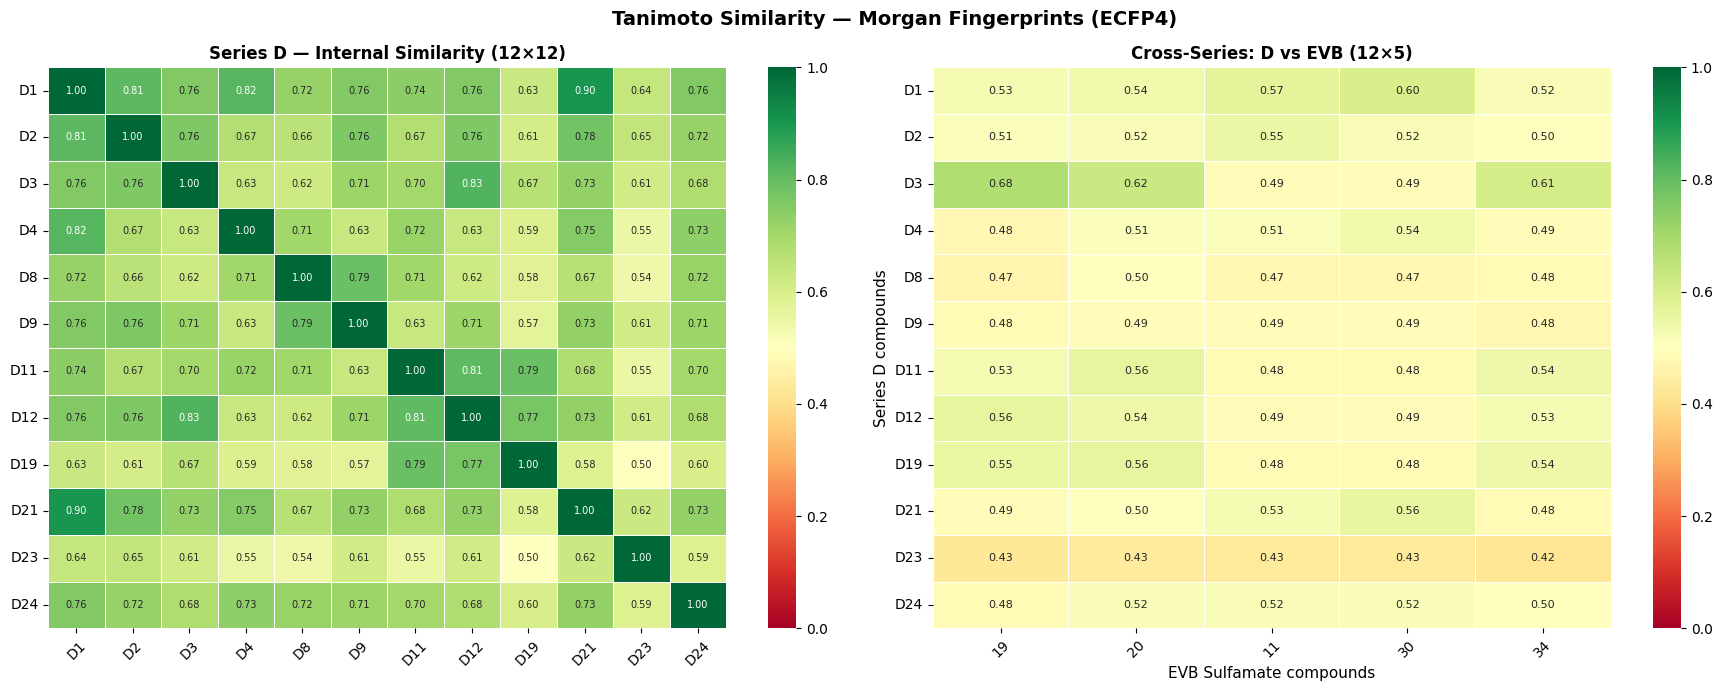

In [ ]:
# ── Helper: build similarity matrix ──────────────────────────
def tanimoto_matrix(fps_a, fps_b):
    matrix = np.zeros((len(fps_a), len(fps_b)))
    for i, fp_a in enumerate(fps_a):
        for j, fp_b in enumerate(fps_b):
            matrix[i, j] = DataStructs.TanimotoSimilarity(fp_a, fp_b)
    return matrix

fps_D   = list(df_D["FP"])
fps_evb = list(df_evb["FP"])

# ── Matrix 1: Series D internal (12×12) ──────────────────────
sim_D = tanimoto_matrix(fps_D, fps_D)

# ── Matrix 2: Cross-series D vs EVB (12×5) ───────────────────
sim_cross = tanimoto_matrix(fps_D, fps_evb)

# ── Plot both heatmaps ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Tanimoto Similarity — Morgan Fingerprints (ECFP4)",
             fontsize=14, fontweight="bold")

# Heatmap 1: Series D internal
sns.heatmap(sim_D,
            ax=axes[0],
            xticklabels=df_D["ID"],
            yticklabels=df_D["ID"],
            annot=True, fmt=".2f", annot_kws={"size": 7},
            cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.5, linecolor="white")
axes[0].set_title("Series D — Internal Similarity (12×12)", fontsize=12, fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)
axes[0].tick_params(axis="y", rotation=0)

# Heatmap 2: Cross-series D vs EVB
sns.heatmap(sim_cross,
            ax=axes[1],
            xticklabels=df_evb["ID"],
            yticklabels=df_D["ID"],
            annot=True, fmt=".2f", annot_kws={"size": 8},
            cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.5, linecolor="white")
axes[1].set_title("Cross-Series: D vs EVB (12×5)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("EVB Sulfamate compounds", fontsize=11)
axes[1].set_ylabel("Series D compounds", fontsize=11)
axes[1].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("tanimoto_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()